basic information of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10956 entries, 0 to 10955
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ZIP        10956 non-null  int64  
 1   SOLDPRICE  10956 non-null  float64
 2   SQFT       10956 non-null  int64  
 3   LOTSIZE    2897 non-null   float64
 4   BEDS       10956 non-null  int64  
 5   BATHS      10956 non-null  float64
 6   AGE        10956 non-null  int64  
 7   DOM        10956 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 684.9 KB
None

the first five rows of the dataset:
    ZIP  SOLDPRICE  SQFT    LOTSIZE  BEDS  BATHS  AGE  DOM
0  2474   410000.0  1368  1306800.0     2    2.0    3  897
1  2124   327000.0  1850     5000.0     2    2.5    5  658
2  2184   331000.0  1469        NaN     2    1.0   38  467
3  1949   580000.0  2945        NaN     2    2.5    4  565
4  2139  1000000.0  2536        NaN     3    2.5    3   56

original 

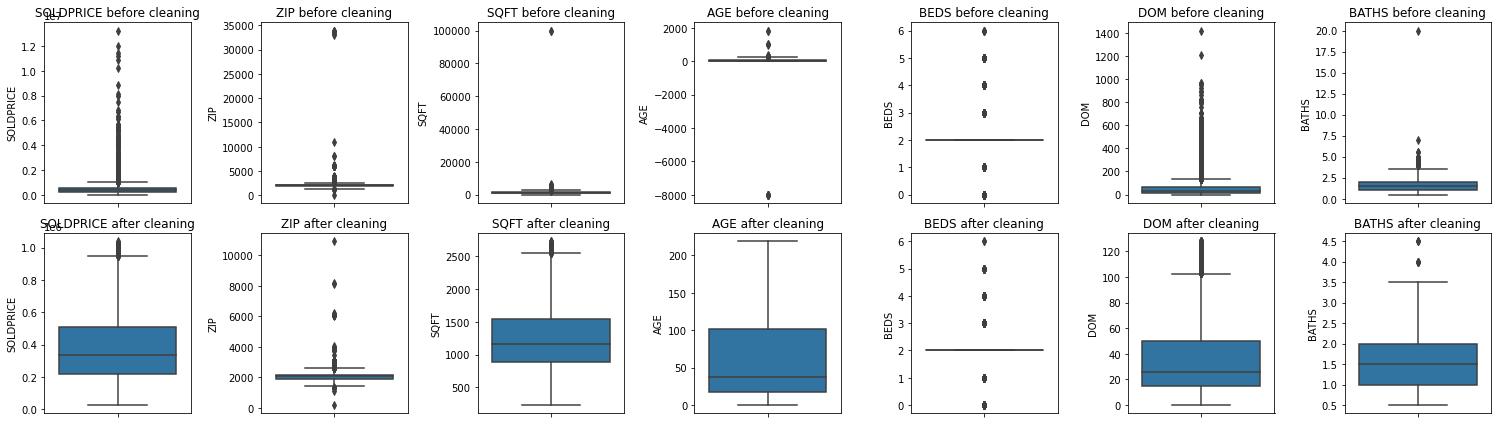


correlation coefficients between features and house prices:
ZIP      0.107181
AGE      0.007615
DOM      0.003444
SQFT     0.002453
BEDS    -0.001844
BATHS   -0.005102
Name: SOLDPRICE, dtype: float64


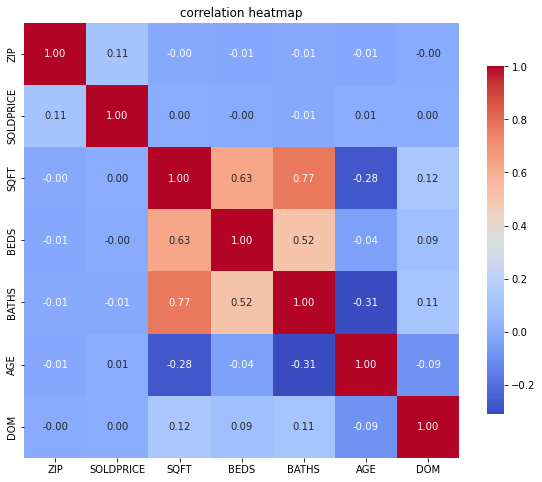

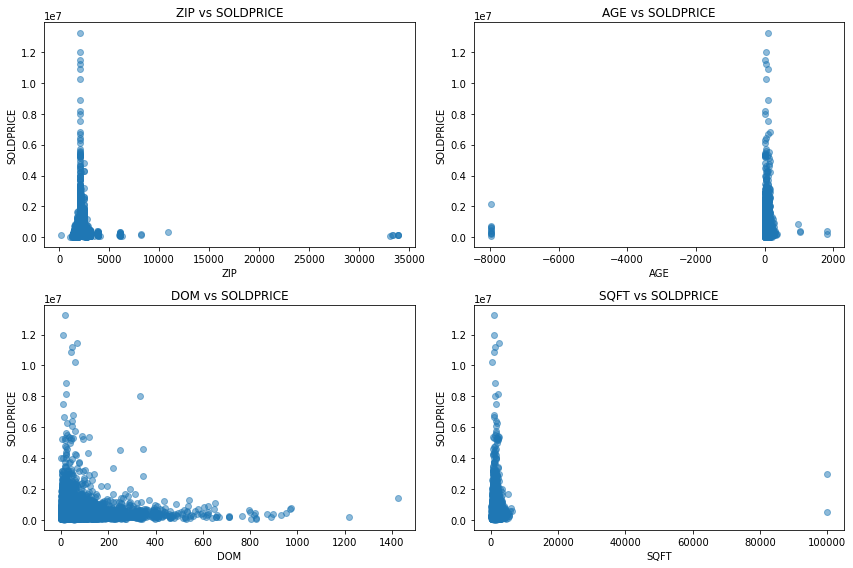

linear regression - Mean Squared Error (MSE): 44720298777.06
linear regression - R²: 0.00
random forest - Mean Squared Error (MSE): 22393336667.46
random forest - R²: 0.50
knn - Mean Squared Error (MSE): 40795766996.83
knn - R²: 0.09
xgboost - Mean Squared Error (MSE): 21867451440.06
xgboost - R²: 0.51


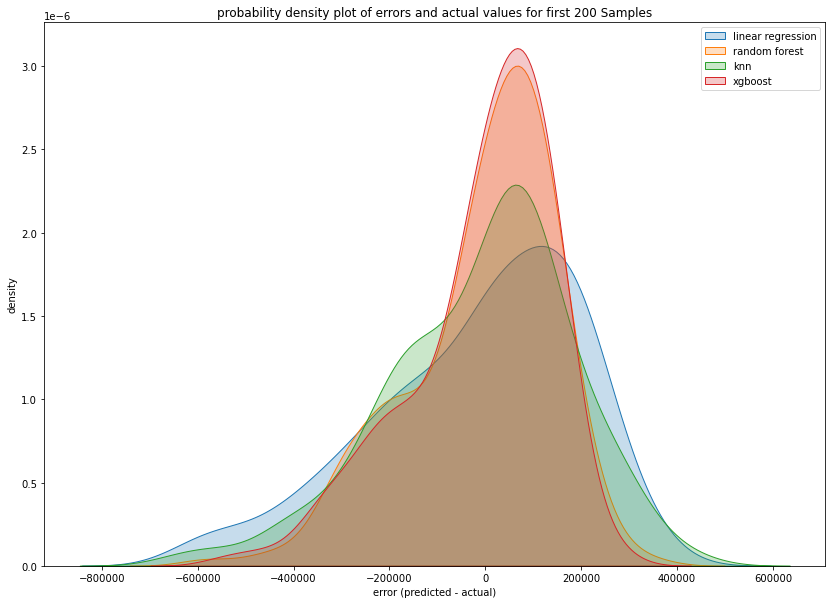

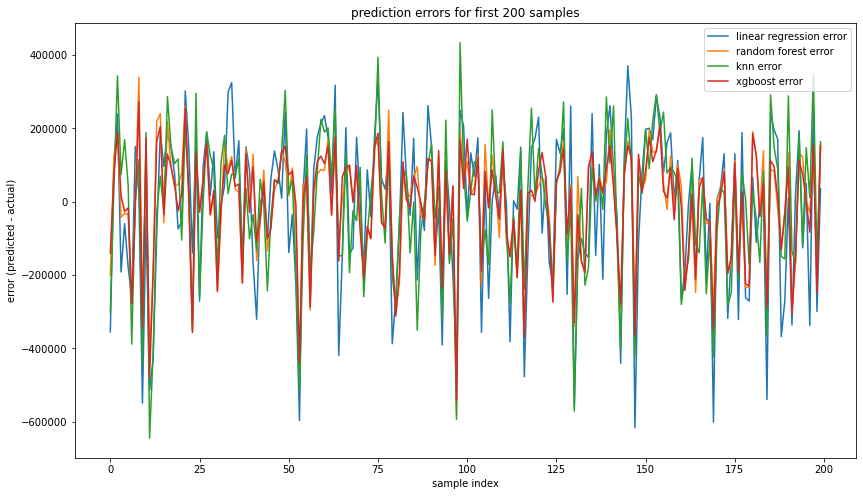

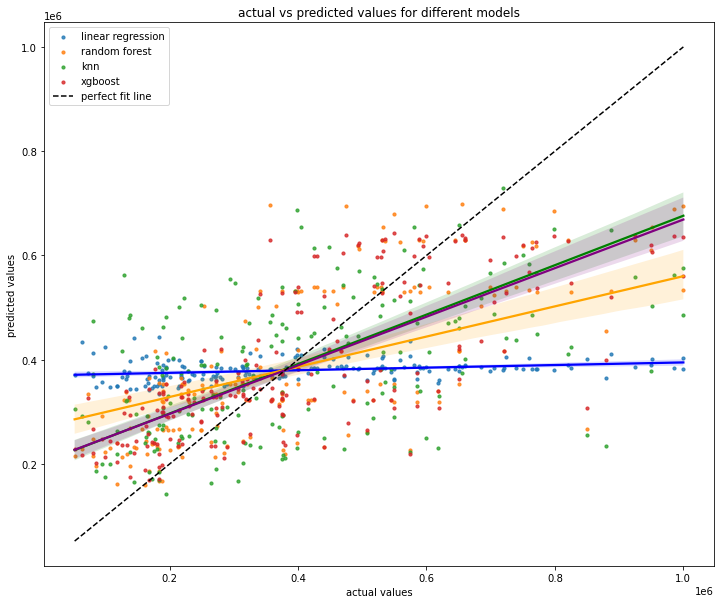

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


class linear_regression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]  
        self.coef_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coef_[0]
        self.coef_ = self.coef_[1:]

    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_

class random_forest:
    def __init__(self, n_trees=100, max_depth=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        for _ in range(self.n_trees):
            indices = np.random.choice(X.shape[0], size=X.shape[0], replace=True)
            X_sample = X[indices]
            y_sample = y[indices]
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(predictions, axis=0)

class knn:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []
        for x_test in X:
            distances = np.linalg.norm(self.X_train - x_test, axis=1)
            k_indices = np.argsort(distances)[:self.n_neighbors]
            k_nearest_values = self.y_train[k_indices]
            predictions.append(np.mean(k_nearest_values))
        return np.array(predictions)

class xgboost:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        y_pred = np.zeros(y.shape)  
        for _ in range(self.n_estimators):
            residuals = y - y_pred
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)  
            y_pred += self.learning_rate * tree.predict(X)  
            self.trees.append(tree)

    def predict(self, X):
        y_pred = np.zeros(X.shape[0])
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred

data = pd.read_csv('CC.csv')

print("basic information of the dataset:")
print(data.info())
print("\nthe first five rows of the dataset:")
print(data.head())
print("\noriginal dataset:")
print(data.describe())
data.drop(columns=['LOTSIZE'], inplace=True)
def handle_outliers_optimized(df):
    df = df[df['ZIP'].between(100, 14925)]

    Q1_price = df['SOLDPRICE'].quantile(0.25)
    Q3_price = df['SOLDPRICE'].quantile(0.75)
    IQR_price = Q3_price - Q1_price
    price_lower_bound = Q1_price - 1.5 * IQR_price
    price_upper_bound = Q3_price + 1.5 * IQR_price
    df = df[(df['SOLDPRICE'] >= price_lower_bound) & (df['SOLDPRICE'] <= price_upper_bound)]

    Q1_sqft = df['SQFT'].quantile(0.25)
    Q3_sqft = df['SQFT'].quantile(0.75)
    IQR_sqft = Q3_sqft - Q1_sqft
    sqft_lower_bound = Q1_sqft - 1.5 * IQR_sqft
    sqft_upper_bound = Q3_sqft + 1.5 * IQR_sqft
    df = df[(df['SQFT'] > 0) & (df['SQFT'] <= sqft_upper_bound) & (df['SQFT'] >= sqft_lower_bound)]

    Q1_age = df['AGE'].quantile(0.25)
    Q3_age = df['AGE'].quantile(0.75)
    IQR_age = Q3_age - Q1_age
    age_lower_bound = Q1_age - 1.5 * IQR_age
    age_upper_bound = Q3_age + 1.5 * IQR_age
    df = df[(df['AGE'] >= age_lower_bound) & (df['AGE'] <= age_upper_bound)]

    df = df[df['BATHS'] <= 6]

    Q1_dom = df['DOM'].quantile(0.25)
    Q3_dom = df['DOM'].quantile(0.75)
    IQR_dom = Q3_dom - Q1_dom
    dom_lower_bound = Q1_dom - 1.5 * IQR_dom
    dom_upper_bound = Q3_dom + 1.5 * IQR_dom
    df = df[(df['DOM'] >= dom_lower_bound) & (df['DOM'] <= dom_upper_bound)]

    return df


data_cleaned = handle_outliers_optimized(data)

print("\ncleaned dataset:")
print(data_cleaned.describe())

def plot_boxplot(data, cleaned_data, columns=['SOLDPRICE', 'ZIP', 'SQFT', 'AGE', 'BEDS', 'DOM', 'BATHS']):
    plt.figure(figsize=(21, 6))
    num_columns = len(columns)
   
    for i, col in enumerate(columns, 1):
        plt.subplot(2, num_columns, i)
        sns.boxplot(data=data, y=col)
        plt.title(f'{col} before cleaning')
        plt.ylabel(col)
       
        plt.subplot(2, num_columns, i + num_columns)
        sns.boxplot(data=cleaned_data, y=col)
        plt.title(f'{col} after cleaning')
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()

plot_boxplot(data, data_cleaned)

correlation_matrix = data_cleaned.corr()
correlation_with_price = correlation_matrix['SOLDPRICE'].drop('SOLDPRICE').sort_values(ascending=False)
print("\ncorrelation coefficients between features and house prices:")
print(correlation_with_price)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('correlation heatmap')
plt.show()

top_features = correlation_with_price.head(4).index
plt.figure(figsize=(12, 8))
for i, feature in enumerate(top_features, start=1):
    plt.subplot(2, 2, i)
    plt.scatter(data[feature], data['SOLDPRICE'], alpha=0.5)
    plt.title(f'{feature} vs SOLDPRICE')
    plt.xlabel(feature)
    plt.ylabel('SOLDPRICE')
plt.tight_layout()
plt.show()

X = data_cleaned[top_features].values
y = data_cleaned['SOLDPRICE'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    'linear regression': linear_regression(),
    'random forest': random_forest(n_trees=100, max_depth=5),
    'knn': knn(n_neighbors=5),
    'xgboost': xgboost(n_estimators=100, learning_rate=0.1, max_depth=3)
}

predictions = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[model_name] = y_pred
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} - Mean Squared Error (MSE): {mse:.2f}")
    print(f"{model_name} - R²: {r2:.2f}")

comparison_df = pd.DataFrame({
    'actual': y_test[:200],
    'linear regression': predictions['linear regression'][:200],
    'random forest': predictions['random forest'][:200],
    'knn': predictions['knn'][:200],
    'xgboost': predictions['xgboost'][:200]
})

plt.figure(figsize=(14, 10))

for model_name in predictions.keys():
    sns.kdeplot(comparison_df[model_name] - comparison_df['actual'], label=model_name, fill=True)


plt.title('probability density plot of errors and actual values for first 200 Samples')
plt.xlabel('error (predicted - actual)')
plt.ylabel('density')
plt.legend()
plt.show()

plt.figure(figsize=(14, 8))

for model_name in predictions.keys():
    errors = comparison_df[model_name] - comparison_df['actual']
    plt.plot(errors, label=f'{model_name} error')

plt.title('prediction errors for first 200 samples')
plt.xlabel('sample index')
plt.ylabel('error (predicted - actual)')
plt.legend()
plt.show()

plt.figure(figsize=(12, 10))

colors = {
    'linear regression': 'blue',
    'random forest': 'green',
    'knn': 'orange',
    'xgboost': 'purple'
}

for model in ['linear regression', 'random forest', 'knn', 'xgboost']:
    sns.regplot(
        x=comparison_df['actual'],
        y=comparison_df[model],
        label=model,
        scatter_kws={'s': 10},
        line_kws={'color': colors[model]}  
    )

plt.plot([comparison_df['actual'].min(), comparison_df['actual'].max()],
         [comparison_df['actual'].min(), comparison_df['actual'].max()],
         'k--', label="perfect fit line")

plt.xlabel("actual values")
plt.ylabel("predicted values")
plt.title("actual vs predicted values for different models")
plt.legend()
plt.show()
